In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.compute as pc
from adam_core.time import Timestamp
from astropy.time import Time
import matplotlib.pyplot as plt
import quivr as qv
import numpy as np
import requests
from typing import Dict, Tuple
from adam_core.constants import DE44X_CONSTANTS

In [2]:
all_data = pq.read_table("../data/paper_data.parquet")

In [3]:
all_data = all_data.sort_by("obstime")

In [4]:
def subset_data(object_id: str, data: pa.Table) -> Tuple[pa.Table, pa.DoubleArray, Dict[str, pa.DoubleArray], Dict[str, pa.DoubleArray]]:
    """Pulls data for the given object from the collection of all data
    
    Returns:
    --------
    obs_time: DoubleArray
      All observation times for the given object as MJD, sorted ascending
    otime: dict[str, Timestamp]
      Dictionary from band color to timestamps for it
    mag: dict[str, DoubleArray]
      Dictionary from band color to magnitudes for it
    """
    selection = data.filter(pc.equal(data["provid"], object_id))
    obs_time = Timestamp.from_astropy(Time(selection["obstime"].to_pylist())).mjd()
    arc_len = pc.max(obs_time).as_py() - pc.min(obs_time).as_py()
    mag = {}
    otime = {}
    # TODO: also "u"? And see other 'spellings' of same 4 colors
    for color in ["g", "i", "r"]:
        mag[color] = selection.filter(pc.equal(selection["band"], color))["mag"].cast('float')
        otime[color] = Timestamp.from_astropy(Time(selection.filter(pc.equal(selection["band"], color))["obstime"]))
    mean_mag_r = pc.mean(mag["r"])
    delta_mag_r = pc.max(mag["r"]).as_py() - pc.min(mag["r"]).as_py()
    print(f"For object {object_id}: num obs {len(selection)}, arc length {arc_len}")
    print(f"Mean mag in r-band {mean_mag_r}, delta mag in r-band {delta_mag_r}")
    print(f"Counts per band: g {len(mag['g'])}, i {len(mag['i'])}, r {len(mag['r'])}")
    assert np.sum([len(v) for v in mag.values()]) == len(selection), "Add missing colors"
    return selection, obs_time, otime, mag

In [5]:
# Pick an object from the paper "2025 MM81"
# should have mag variation 1.2, period 0.045 days ~= 1.1h
# from page 11 of the paper for 2025MM81:
# H mag = 21.1, mean mag r-band = 22.90, num obs=390, arc (days) 9,
# period (LSM/Furier) 1.1/1.1,
# Amplitude LSM/Furier 1.0/1.2, g-r LSM/Furier 0.55/0.53, g-i LSM/Furier 0.67/0.66,
# r-i LSM/Furier 0.12/0.12, axial elongation 2.1
mm81_id = "2025 MM81"
mm81_selection, mm81_obstime, mm81_otime, mm81_mag = subset_data(mm81_id, all_data)

For object 2025 MM81: num obs 390, arc length 9.035824999999022
Mean mag in r-band 22.902367843978706, delta mag in r-band 1.4479999542236328
Counts per band: g 127, i 89, r 174


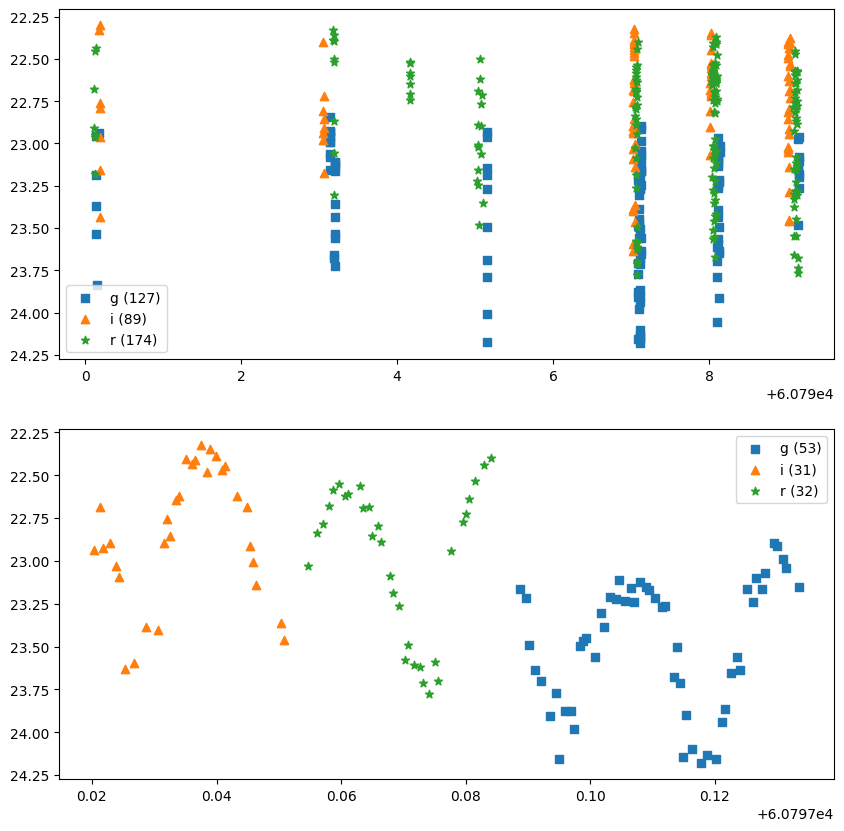

In [6]:
# Repro Figure 8 from the paper
def show_figure8(obs_time, otime, mag, first_day: float):
    """Draw figure similar to Figure8 in the paper.
    Parameters:
    -----------
    obs_time:
      sorted list of all observation times for the given object

    """
    # print(pc.min(otime["g"].mjd()), pc.max(otime["g"].mjd()))
    _fig, axs = plt.subplots(2, 1, figsize=(10, 10))
    axs[0].scatter(otime["g"].mjd().to_pylist(), mag["g"].to_pylist(), marker="s", c="tab:blue", label=f"g ({len(mag['g'])})")
    axs[0].scatter(otime["i"].mjd().to_pylist(), mag["i"].to_pylist(), marker="^", c="tab:orange", label=f"i ({len(mag['i'])})")
    axs[0].scatter(otime["r"].mjd().to_pylist(), mag["r"].to_pylist(), marker="*", c="tab:green", label=f"r ({len(mag['r'])})")
    axs[0].legend()
    axs[0].invert_yaxis()

    # Find the night with the observation count matching Figure 8 in the paper
    beginning_of_time = pc.min(obs_time).as_py() - 0.25
    start_time = beginning_of_time + first_day # 6 is the number that matched the count
    end_time = start_time + 1.5 # make sure to get the whole night

    selected_times = {}
    selected_mags = {}
    for color in ["g", "i", "r"]:
        index = pc.and_(pc.greater(otime[color].mjd(), start_time), pc.less(otime[color].mjd(), end_time))
        selected_times[color] = otime[color].mjd().to_numpy()[index]
        selected_mags[color] = mag[color].to_numpy()[index]
    axs[1].scatter(selected_times["g"], selected_mags["g"], marker="s", c="tab:blue", label=f"g ({len(selected_mags['g'])})")
    axs[1].scatter(selected_times["i"], selected_mags["i"], marker="^", c="tab:orange", label=f"i ({len(selected_mags['i'])})")
    axs[1].scatter(selected_times["r"], selected_mags["r"], marker="*", c="tab:green", label=f"r ({len(selected_mags['r'])})")
    axs[1].legend()
    axs[1].invert_yaxis()

    plt.show()

show_figure8(mm81_obstime, mm81_otime, mm81_mag, 6)

In [7]:
# Page 6: "heliocentric and topocentric distances, r and Δ, respectively, as well as the
# phase angles, α, were obtained via the NASA Horizons API"
class RotationalPeriodInput(qv.Table):
    object_id = qv.LargeStringColumn()
    obs_time = Timestamp.as_column()
    sun_range = qv.Float64Column()
    obs_range = qv.Float64Column()
    angle = qv.Float64Column()

def _parse_rotational_period_input_response(object_id: str, text: str) -> RotationalPeriodInput:
    lines = text.splitlines()
    row = 0
    while row < len(lines) and not lines[row].startswith("$$SOE"):
        row += 1
    row += 1
    jd = []
    sun_range = []
    obs_range = []
    angle = []
    while row < len(lines) and not lines[row].startswith("$$EOE"):
        parts = lines[row].split(",")
        # text date, JD data, solar presence, lunar presence, sun range to target AU,
        # observer range to target AU, Sun-Target-Observer angle degrees, <-- extra comma
        assert len(parts) >= 7, f"Actual length {len(parts)}: {parts}"
        jd.append(float(parts[1]))
        sun_range.append(float(parts[4]))
        obs_range.append(float(parts[5]))
        angle.append(float(parts[6]))
        row += 1
    return RotationalPeriodInput.from_kwargs(
        object_id = [object_id] * len(jd),
        obs_time = Timestamp.from_jd(jd),
        sun_range = sun_range,
        obs_range = obs_range,
        angle = angle,
    )


def _query_rotational_period_inputs(object_id: str, stn: str, obs_times: pa.DoubleArray) -> RotationalPeriodInput:
    API_URL = "https://ssd.jpl.nasa.gov/api/horizons.api"
    chunk_size = 30 # 100 is too much
    start_chunk = 0
    sess = requests.Session() # TODO: parallel queries?
    # Selected: 
    # "19: heliocentric range and range rate"
    # "20: observer range and range rate"
    # "24: Sun-target-observer ~PHASE angle"
    # Suppress rates, only use ranges
    params = {
        "format": "text",
        "COMMAND": f"'DES={object_id};'",
        "OBJ_DATA": "NO", # default YES
        # "MAKE_EPHEM": "YES", # default
        #"EPHEM_TYPE": "OBSERVER", # default
        "CENTER": stn,
        "TIME_TYPE": "UT",
        "TLIST_TYPE": "MJD",
        "QUANTITIES": "'19,20,24'",
        "CAL_FORMAT": "BOTH", # CAL & JD
        "CSV_FORMAT": "YES",
        # "RANGE_UNITS": "AU", # default
        "SUPPRESS_RANGE_RATE": "YES", # default NO
    }
    collections = []
    while start_chunk < len(obs_times):
        tlist = [f"'{v}'" for v in obs_times[start_chunk:start_chunk+chunk_size]]
        start_chunk += chunk_size
        params["TLIST"] = " ".join(tlist)
        resp = sess.get(
            API_URL, params=params, timeout=10
        )
        resp.raise_for_status()
        collections.append(_parse_rotational_period_input_response(object_id, resp.text))
    return qv.concatenate(collections)

def cache_or_query_rotational_period_inputs(object_id: str,
                                            stn: str,
                                            obs_times: pa.DoubleArray,
                                            cache_file: str = "../data/rot_period_inputs.parquet",
                                            force_query: bool = False) -> RotationalPeriodInput:
    
    try:
        input_data = RotationalPeriodInput.from_parquet(cache_file)
        print(f"Read total {len(input_data)} records")
    except:
        print(f"Failed to read {cache_file}")
        input_data = RotationalPeriodInput.empty()
    result = input_data.apply_mask(pc.equal(input_data.object_id, object_id))
    if force_query or len(result) == 0:
        print(f"Query API for {object_id} and {len(obs_times)} timestamps")
        result = _query_rotational_period_inputs(object_id, stn, obs_times)
        input_data = qv.concatenate([
            input_data.apply_mask(pc.not_equal(input_data.object_id, object_id)),
            result,
            ])
        input_data.to_parquet(cache_file)
    return result


In [8]:
mm81_inputs = cache_or_query_rotational_period_inputs(mm81_id, "X05", mm81_obstime)
mm81_inputs

Read total 390 records


RotationalPeriodInput(size=390)

In [9]:
# High-order Fourier Analysis

def _adjust_inputs_for_fourier(observation_table: pa.Table, range_inputs: RotationalPeriodInput,
                              obs_time: pa.DoubleArray) -> Tuple[np.ndarray, np.ndarray]:
    # Sanity that the arrays are sorted, so we can just match indexes
    deltas = pc.subtract(obs_time, range_inputs.obs_time.mjd())
    assert pc.max(pc.abs(deltas)).as_py() < 1e-9

    observed_mags = np.array([float(v) for v in observation_table["mag"]])
    helio_r = range_inputs.sun_range.to_numpy()
    topo_delta = range_inputs.obs_range.to_numpy()
    alpha = range_inputs.angle.to_numpy()
    print(f"Alpha range {np.min(alpha)} - {np.max(alpha)}")

    # Page 6, section 3.1
    # Subtract 5*log10(r*delta) from observational magnitudes
    # print(f"Sizes V={observed_mags.shape}, r={helio_r.shape}, delta={topo_delta.shape}, alpha={alpha.shape}")
    observed_mags = observed_mags - 5*np.log10(helio_r * topo_delta)

    # Correct timing for speed of light: t = t_obs - delta/c
    observed_time = obs_time - topo_delta / DE44X_CONSTANTS["C"]
    return observed_time, observed_mags

def _fit_fourier(freq: float, k: int, obs_v, obs_t, alpha, bands, weights) -> Tuple[np.ndarray, float, int]:
    # return values, sigma2, np.sum(included)


    # Model phi(alpha) = c1*alpha + c2*alpha^2
    # g (t ) = sum(j=1:k) Aj*cos (2 fjt ) + Bj*sin (2 fjt ) for k 2:6
    # X=[c1, c2, A1, B1, ..., Ak, Bk, Hg, Hi, Hr, <H?,> ], B == obs_v
    num_params = 2 + 2*k +3
    num_obs = len(obs_v)
    A = np.zeros((num_obs, num_params))
    # print(f"Shapes A={A.shape} alpha={alpha.shape} alpha^2={(alpha*alpha).shape} V={obs_v.shape} t={obs_t.shape} weights={weights.shape}")

    A[:, 0] = alpha # *c1
    A[:, 1] = alpha*alpha # *c2
    # Fourier coeffs
    base = 2*np.pi*freq*obs_t
    idx = 2
    for j in range(1, k+1):
        arg = base * j
        A[:, idx] = np.cos(arg)
        A[:, idx+1] = np.sin(arg)
        idx+=2
    # Pick color
    for i in range(num_obs):
        color = bands[i].as_py()
        # TODO: compress with hashmap
        if color == "g":
            A[i, idx] = 1
        elif color == "i":
            A[i, idx+1] = 1
        elif color == "r":
            A[i, idx+2] = 1
        else:
            raise BaseException(f"Bad color [{color}] index {i}")
    # Build weighted matrices
    W = np.diag(np.sqrt(weights))
    Aw = np.dot(W, A)
    Bw = np.dot(obs_v, W)

    # May need to throw away outliers
    converged = False
    included = np.array([True] * num_obs)
    while not converged:
        values, _residuals, rank, singulars = np.linalg.lstsq(Aw[included, :], Bw[included])
        assert rank == num_params
        assert len(singulars) == rank

        # Compute p_j*(Oj-Cj)^2
        res = (obs_v - A @ values)**2 * weights # this includes already rejected, it's okay
        n_incl = np.sum(included)
        sigma2 = np.sum(res[included]) / (n_incl - num_params) # discard rejected here
        outliers = res > 9*sigma2 # not masking here, because included accumulates
        # Converged if there are no NEW outliers
        converged = np.sum(outliers[included]) == 0
        included = included & ~outliers

    return values, num_obs * sigma2 / np.sum(weights), np.sum(included)

def _get_freqs(fmin: float, fmax: float, arc_len: float) -> np.ndarray:
    N = int(30 * arc_len * (fmax - fmin))
    return np.linspace(fmin, fmax, num=N)

def run_fourier(observation_table: pa.Table, range_inputs: RotationalPeriodInput, obs_time: pa.DoubleArray, 
                min_freq: float = 0.1667, max_freq: float = 500):
    observed_time, observed_mags = _adjust_inputs_for_fourier(observation_table, range_inputs, obs_time)
    arc_length = np.max(obs_time) - np.min(obs_time)
    freqs = _get_freqs(min_freq, max_freq, arc_length)
    print(f"Freqs count {freqs.shape}, arc length={arc_length}")

    alpha = range_inputs.angle.to_numpy()
    alpha = np.deg2rad(alpha)

    # print("Colors", pc.unique(observation_table["band"]).to_pylist())
    weights = 1/(np.array([float(w) for w in observation_table["rmsmag"]]) ** 2)

    # Page 7: for each k, find freq that gives minumum sigma2 for that k
    result = []
    for k in range(2, 7):
        best_sigma2 = np.inf
        best_fit = None
        best_freq = np.inf
        best_size = np.inf
        for f in freqs:
            X, sigma2, n_incl = _fit_fourier(f, k, observed_mags, observed_time, alpha, observation_table["band"], weights)
            if sigma2 < best_sigma2:
                best_sigma2 = sigma2
                best_fit = X
                best_freq = f
                best_size = n_incl
        print(f"For k={k} got best freq {best_freq} with sigma={best_sigma2} H={best_fit[-3:]} N={best_size} -> period = {24.0 / best_freq} h")
        result.append((k, best_sigma2, best_freq, best_fit, best_size))
    return result


In [10]:
fit_mm81 = run_fourier(mm81_selection, mm81_inputs, mm81_obstime)

Alpha range 18.2055 - 22.3731
Freqs count (135492,), arc length=9.035824999999022
For k=2 got best freq 21.79929900067163 with sigma=0.010866096109927963 H=[21.36254731 20.7180653  20.84642056] N=389 -> period = 1.100952833357649 h
For k=3 got best freq 21.7956099490003 with sigma=0.009522658117028933 H=[18.88702026 18.23866241 18.36096478] N=388 -> period = 1.1011391769332342 h
For k=4 got best freq 21.7956099490003 with sigma=0.008017566960793717 H=[18.09285117 17.44108888 17.56425   ] N=389 -> period = 1.1011391769332342 h
For k=5 got best freq 21.7956099490003 with sigma=0.007887930743097385 H=[18.13139673 17.47916186 17.60240217] N=389 -> period = 1.1011391769332342 h
For k=6 got best freq 21.7956099490003 with sigma=0.007901071413747417 H=[18.17856877 17.52705259 17.64945367] N=389 -> period = 1.1011391769332342 h


In [ ]:
import scipy
def best_row_by_f(fourier_result):
    alpha = 0.05
    best_row = 0
    best_row_changed = True
    while best_row_changed:
        best_row_changed = False
        k_i, sigma2_i, freq_i, fit_i, size_i = fourier_result[best_row]
        for j in range(best_row+1, len(fourier_result)):
            k_j, sigma2_j, freq_j, fit_j, size_j = fourier_result[j]
            F = sigma2_i / sigma2_j
            p = 1-scipy.stats.f.cdf(F, size_i-1, size_j-1)

            print(f"K={k_i},{k_j} sigmas2={sigma2_i},{sigma2_j} F={F}, p={p}")
            if p < alpha and sigma2_j < sigma2_i:
                # Reject sigma_i == sigma_j
                # Model j is "significantly better"
                print(f"Switch best row to {j}")
                best_row = j
                best_row_changed = True
                break
    print(f"Best row={best_row} for k={fourier_result[best_row][0]}")
    return fourier_result[best_row]

best_fit_mm81 = best_row_by_f(fit_mm81)



K=2,3 sigmas2=0.010866096109927963,0.009522658117028933 F=1.141078045267279, p=0.0972191890754428
K=2,4 sigmas2=0.010866096109927963,0.008017566960793717 F=1.355285981777725, p=0.0014108661911236275
Switch best row to 2
K=4,5 sigmas2=0.008017566960793717,0.007887930743097385 F=1.0164347560746239, p=0.4362658322575077
K=4,6 sigmas2=0.008017566960793717,0.007901071413747417 F=1.0147442721304358, p=0.4427263032417649
Best row=2 for k=4


Count of local maxima 2, G size 1000
Amplitude 0.9629135263536839


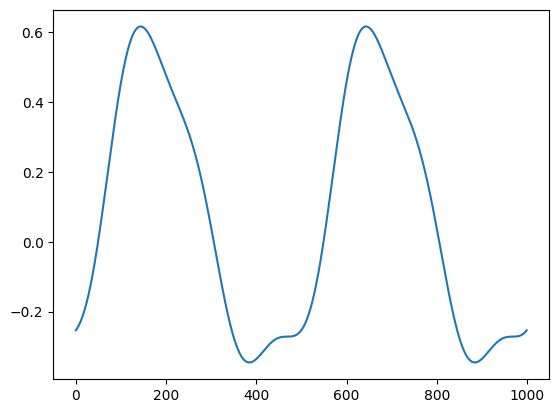

Colors g-r=0.5286011700395612 g-i=0.6517622894732149 r-i=0.12316111943365371
Elongation=2.411675498923441
Best ampl,g-r,g-i,r-i (np.float64(0.9629135263536839), np.float64(0.5286011700395612), np.float64(0.6517622894732149), np.float64(0.12316111943365371), np.float64(2.411675498923441)) for k=4


In [ ]:
def amplitude(fit, alpha_avg):
    k, sigma2, freq, values, size = fit
    period_days = 1 / freq
    sample = np.linspace(0, 2*period_days, num=1000)
    base = 2*np.pi*freq*sample
    G = np.zeros((len(sample)))
    assert len(values) == 2+k*2+3
    for j in range(0, k):
        arg = base * j
        G += values[2+2*j]*np.cos(arg)
        G += values[2+2*j+1]*np.sin(arg)
        # print(f"A{j} -> {2+2*j}")
    ampl = np.max(G) - np.min(G)

    # Count maxima
    max_count = 0
    for i in range(1, len(G)-1):
        if G[i-1]<G[i] and G[i]>=G[i+1]:
            max_count += 1
    print(f"Count of local maxima {max_count}, G size {len(G)}")

    print(f"Amplitude {ampl}")
    plt.plot(G)
    # plt.plot(G[440:480])
    plt.show()

    H_g = values[2+2*k]
    H_i = values[2+2*k+1]
    H_r = values[2+2*k+2]
    assert 2+2*k+2 == len(values)-1
    print(f"Colors g-r={H_g-H_r} g-i={H_g-H_i} r-i={H_r-H_i}")

    A0 = ampl / (1 + 0.02*alpha_avg)
    elongation = 10 ** (0.4*A0)
    print(f"Elongation={elongation}")
    # print(G[440:480])
    return ampl, H_g-H_r, H_g-H_i, H_r-H_i, elongation

# Expected for 2025 MM81: 1.1, 0.55, 0.67, 0.12, 2.1
print(f"Best ampl,g-r,g-i,r-i {amplitude(best_fit_mm81, np.deg2rad(np.average(mm81_inputs.angle)))} for k={best_fit_mm81[0]}")
# for row in fit_mm81:
#     print(f"k={row[0]}, ample={amplitude(row)}")

For object 2025 MM81: num obs 390, arc length 9.035824999999022
Mean mag in r-band 22.902367843978706, delta mag in r-band 1.4479999542236328
Counts per band: g 127, i 89, r 174
Corrections alpha=4.280979813799351 mag=0.8924672011176435 ampl=0.9627362733684386


/tmp/ipykernel_1432/3187281189.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


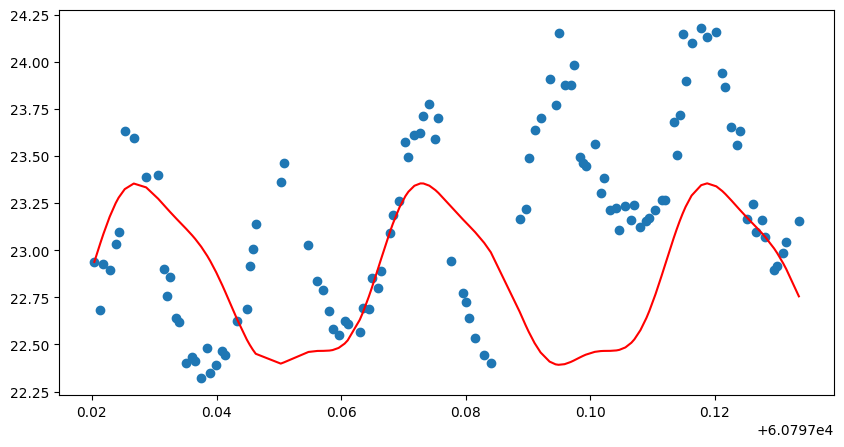

In [123]:
def viz_vs_data(id, day, inputs, id_fit):
    k, sigma2, freq, values, size = id_fit
    fig, ax = plt.subplots(1,1, figsize=(10, 5))
    id_selection, id_obstime, id_otime, id_mag = subset_data(id, all_data)
    id_obstime = id_obstime.to_numpy()
    mag = id_selection["mag"].cast('float').to_numpy()
    start_time = np.min(id_obstime) - 0.25
    if day is not None:
        start_time += day
        index = (id_obstime > start_time) & (id_obstime < (start_time+1))
    else:
        index = np.array([True] * len(id_obstime))

    alpha = np.deg2rad(inputs.angle)[0]
    alpha_corr = values[0]*alpha + values[1]*alpha*alpha
    helio_r = inputs.sun_range.to_numpy()[0]
    topo_delta = inputs.obs_range.to_numpy()[0]
    mag_corr = 5*np.log10(helio_r * topo_delta)


    times = id_obstime[index] # np.linspace(np.min(id_obstime[index]), np.max(id_obstime[index]), num=100)
    base = 2*np.pi*freq*times
    G = np.zeros((len(times)))
    assert len(values) == 2+k*2+3
    for j in range(0, k):
        arg = base * j
        G += values[2+2*j]*np.cos(arg)
        G += values[2+2*j+1]*np.sin(arg)
        # print(f"A{j} -> {2+2*j}")
    H_g = values[2+2*k]
    H_i = values[2+2*k+1]
    H_r = values[2+2*k+2]
    G += H_r + alpha_corr + mag_corr
    print(f"Corrections alpha={alpha_corr} mag={mag_corr} ampl={np.max(G)-np.min(G)}")

    # index = range(100, 200)
    ax.scatter(id_obstime[index], mag[index])
    ax.plot(times, G, color="r")
    ax.yaxis_inverted()
    fig.show()

viz_vs_data(mm81_id, 7, mm81_inputs, best_fit_mm81)

In [ ]:
# Try 2025 MA46. Expect H=18.1, mean mag r band=23.13, num obs 291, arc 12, period 5.9, ampl 0.6
# g-r=0.53, g-i=0.71, r-i=0.18, elong=1.6
ma46_id = "2025 MA46"
ma46_selection, ma46_obstime, ma46_otime, ma46_mag = subset_data(ma46_id, all_data)
ma46_inputs = cache_or_query_rotational_period_inputs(ma46_id, "X05", ma46_obstime)
ma46_selection["band"].unique().to_pylist()


For object 2025 MA46: num obs 291, arc length 12.043866203704965
Mean mag in r-band 23.131196946808785, delta mag in r-band 1.055999755859375
Counts per band: g 85, i 74, r 132
Read total 681 records


[
  "i",
  "r",
  "g"
]

In [48]:
fit_ma46 = run_fourier(ma46_selection, ma46_inputs, ma46_obstime)

Alpha range 8.5212 - 11.7002
Freqs count (180597,), arc length=12.043866203704965
For k=2 got best freq 8.18192313229529 with sigma=0.015325891477838896 H=[14.70927687 14.04935442 14.183315  ] N=290 -> period = 2.9332957071264043 h
For k=3 got best freq 8.187458507386655 with sigma=0.015106980501649173 H=[13.23939041 12.55068092 12.71182102] N=290 -> period = 2.931312565229785 h
For k=4 got best freq 8.190226194932336 with sigma=0.015085161682622524 H=[13.07118592 12.36900667 12.53490779] N=290 -> period = 2.93032199951326 h
For k=5 got best freq 1.6363420867571818 with sigma=0.014855228743954877 H=[17.05814306 16.31309823 16.55814829] N=290 -> period = 14.666859817534828 h
For k=6 got best freq 2.3946884742740706 with sigma=0.015096440649259725 H=[7.07030132 6.39244074 6.49345105] N=291 -> period = 10.022180445527637 h


K=2,3 sigmas2=0.015325891477838896,0.015106980501649173 F=1.0144907168024626, p=0.4513778615185704
K=2,4 sigmas2=0.015325891477838896,0.015085161682622524 F=1.0159580520435312, p=0.44652121651213594
K=2,5 sigmas2=0.015325891477838896,0.014855228743954877 F=1.0316833043769553, p=0.3955450937432443
K=2,6 sigmas2=0.015325891477838896,0.015096440649259725 F=1.0151990017985082, p=0.4489608785311272
Best row=0 for k=2
Count of local maxima 2, G size 1000
Amplitude 0.1004547159794137


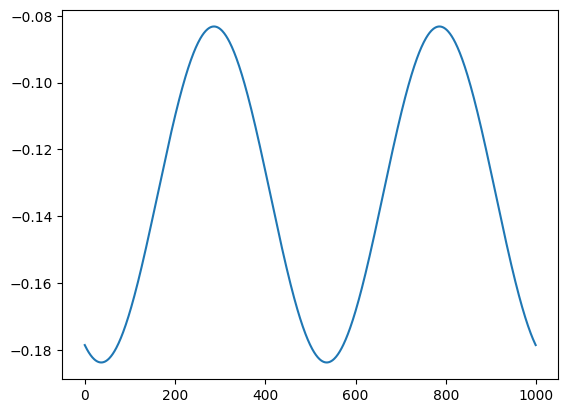

Colors g-r=0.5259618663209693 g-i=0.6599224451664725 r-i=0.13396057884550316
Elongation=1.0965507393784364


In [66]:
best_fit_ma46 = best_row_by_f(fit_ma46)
colors_ma46 = amplitude(best_fit_ma46, np.deg2rad(np.average(ma46_inputs.angle)))
# print(f"Best ampl,g-r,g-i,r-i {amplitude(best_fit_ma46, np.deg2rad(np.average(ma46_inputs.angle)))} for k={best_fit_ma46[0]}")

(2, np.float64(0.015325891477838896), np.float64(8.18192313229529), array([ 4.65998533e+01, -1.23488175e+02, -1.33450436e-01,  2.59075687e-01,
       -4.50204389e-02, -2.22701209e-02,  1.47092769e+01,  1.40493544e+01,
        1.41833150e+01]), np.int64(290))
For object 2025 MA46: num obs 291, arc length 12.043866203704965
Mean mag in r-band 23.131196946808785, delta mag in r-band 1.055999755859375
Counts per band: g 85, i 74, r 132
Corrections alpha=4.199092951631629 mag=4.554871554964411 ampl=0.10033966751865009


/tmp/ipykernel_1432/3187281189.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


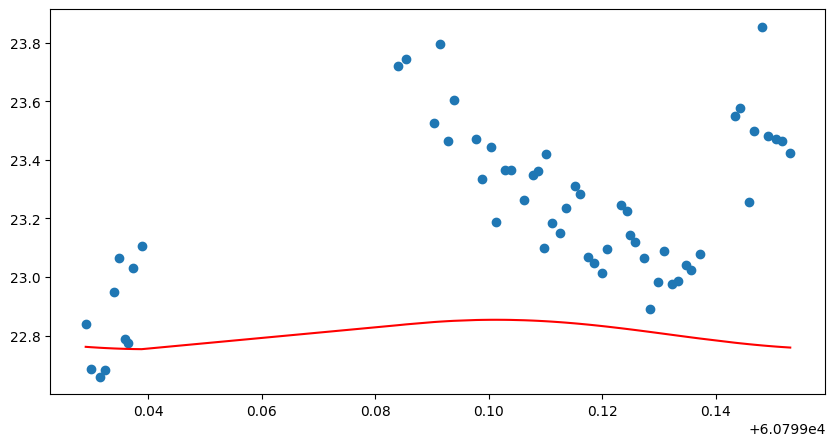

In [124]:
print(best_fit_ma46)
viz_vs_data(ma46_id, 12, ma46_inputs, best_fit_ma46)

In [130]:
def run_all(id: str):
    #_id = "2025 MA46"
    id_selection, id_obstime, id_otime, id_mag = subset_data(id, all_data)
    id_inputs = cache_or_query_rotational_period_inputs(id, "X05", id_obstime)
    print(f"All colors {id_selection['band'].unique().to_pylist()}")
    id_fit = run_fourier(id_selection, id_inputs, id_obstime)
    id_best_fit = best_row_by_f(id_fit)
    id_colors = amplitude(id_best_fit, np.deg2rad(np.average(id_inputs.angle)))
    return id_inputs, id_best_fit, id_colors, id_fit


For object 2025 MD38: num obs 427, arc length 12.046303101851663
Mean mag in r-band 22.803186846303415, delta mag in r-band 1.6270008087158203
Counts per band: g 135, i 110, r 182
Read total 1108 records
All colors ['i', 'r', 'g']
Alpha range 9.1662 - 12.5762
Freqs count (180634,), arc length=12.046303101851663
For k=2 got best freq 6.0689682948298485 with sigma=0.005619330518611044 H=[14.415349   13.79660056 13.94757459] N=405 -> period = 3.954543644666193 h
For k=3 got best freq 5.058969266413114 with sigma=0.005483327111374629 H=[17.8727654  17.27576742 17.40024407] N=427 -> period = 4.744049377674193 h
For k=4 got best freq 4.04897023799638 with sigma=0.005315151168707042 H=[17.70582234 17.13116812 17.24883194] N=427 -> period = 5.9274330482301405 h
For k=5 got best freq 5.058969266413114 with sigma=0.005291665159624066 H=[17.5377933  16.96207741 17.08356013] N=427 -> period = 4.744049377674193 h
For k=6 got best freq 4.04897023799638 with sigma=0.005251357652743325 H=[17.41204581 

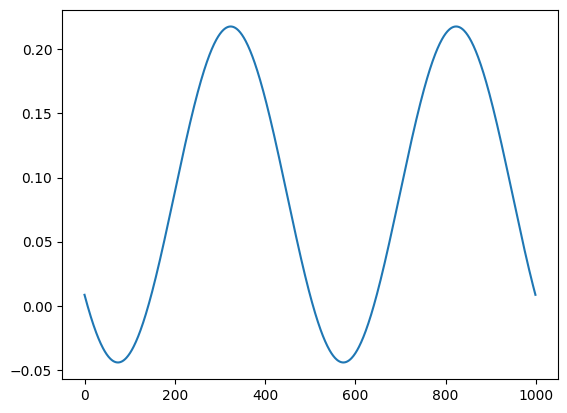

Colors g-r=0.46777440573420037 g-i=0.6187484334497917 r-i=0.15097402771559132
Elongation=1.2718315103809548


In [118]:
md38_inputs, md38_best_fit, md38_colors = run_all("2025 MD38")
# Expect H=18.0, mag r-band 22.80, obs 458, arc 12, period 15.8/9.5, 
# ampl 1.1/1.1, colors 0.46/0.46, 0.54/0.59, 0.08/0.13, elongation 2.2

For object 2025 MD38: num obs 427, arc length 12.046303101851663
Mean mag in r-band 22.803186846303415, delta mag in r-band 1.6270008087158203
Counts per band: g 135, i 110, r 182
Corrections alpha=4.320416460826944 mag=4.141759438676816 ampl=0.2578175969538492


/tmp/ipykernel_1432/3187281189.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


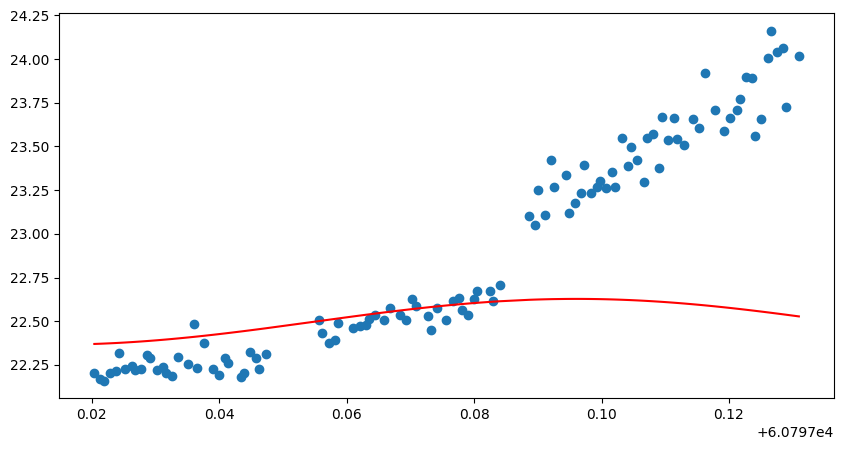

In [125]:
viz_vs_data("2025 MD38", 10, md38_inputs, md38_best_fit)


For object 2025 MZ78: num obs 167, arc length 4.125476597226225
Mean mag in r-band 23.20521438689459, delta mag in r-band 1.0520000457763672
Counts per band: g 36, i 47, r 84
Read total 1275 records
All colors ['r', 'i', 'g']
Alpha range 9.6092 - 10.5843
Freqs count (61861,), arc length=4.125476597226225
For k=2 got best freq 40.08225935984481 with sigma=0.014763582477057263 H=[16.07422611 15.4800447  15.62119102] N=166 -> period = 0.5987686418706144 h
For k=3 got best freq 20.03559887972842 with sigma=0.013751327758444952 H=[17.97983592 17.37416422 17.51343114] N=167 -> period = 1.1978678623019687 h
For k=4 got best freq 20.03559887972842 with sigma=0.013695973448246282 H=[18.24037898 17.63624957 17.78017346] N=167 -> period = 1.1978678623019687 h
For k=5 got best freq 20.03559887972842 with sigma=0.013775486506718707 H=[18.91617192 18.31036883 18.45499367] N=167 -> period = 1.1978678623019687 h
For k=6 got best freq 6.679238632395732 with sigma=0.013593600363226106 H=[16.29190652 15.

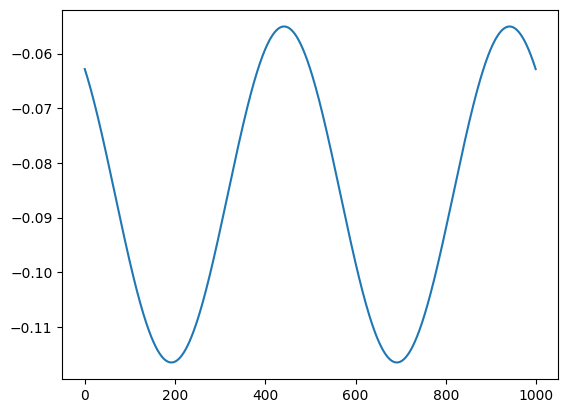

Colors g-r=0.45303508322134434 g-i=0.5941814079260404 r-i=0.141146324704696
Elongation=1.0579889861079286


In [131]:
mz78_inputs, mz78_best_fit, mz78_colors, mz78_allfit = run_all("2025 MZ78")
# Expect H=17.8, mag r-band 23.21, obs 167, arc 4, period 1.2/1.2,
# ampl 0.5/0.5, colors 0.46/0.46, 0.58/0.60, 0.12/0.14, elong 1.5

For object 2025 MZ78: num obs 167, arc length 4.125476597226225
Mean mag in r-band 23.20521438689459, delta mag in r-band 1.0520000457763672
Counts per band: g 36, i 47, r 84
Corrections alpha=0.7646824091179807 mag=4.931635829978736 ampl=0.43968572984258714


/tmp/ipykernel_1432/3187281189.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


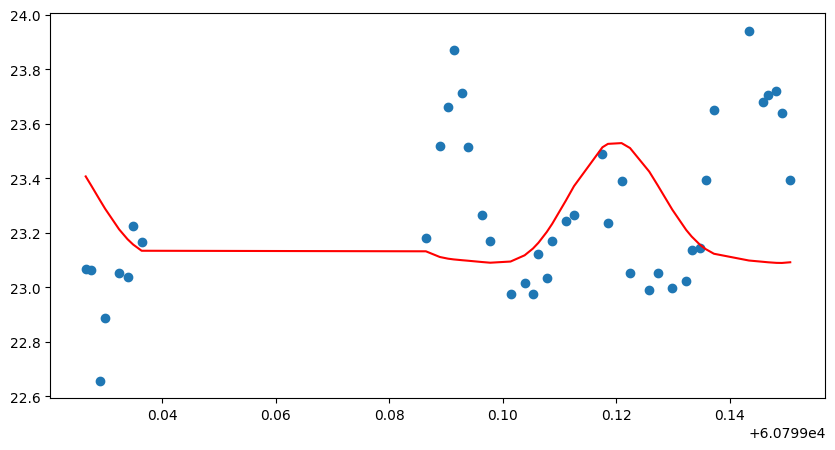

In [132]:
viz_vs_data("2025 MZ78", 4, mz78_inputs, mz78_allfit[1]) # mz78_best_fit)